# Polygon.io Familiarity - How to get historical option data

Focus: Pull one day of historical option data using he Polygon.io API

Notes:
- This is the way I am currently planning on getting historical options data becuase Yfinance does not track historical options data.


In [1]:
from massive import RESTClient
import datetime as dt 
import pandas as pd 
import plotly.graph_objects as go

import sys
from pathlib import Path

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))
from src.polygonAPIkey import polygonAPIkey

In [2]:
client = RESTClient(polygonAPIkey)
dataRequest = client.get_aggs(ticker='AAPL', 
                              multiplier=1, 
                              timespan='day', 
                              from_='2025-01-01', 
                              to='2025-12-31')
dataRequest[0]

Agg(open=248.93, high=249.1, low=241.8201, close=243.85, volume=55090731.0, vwap=244.346, timestamp=1735794000000, transactions=685447, otc=None)

In [22]:
import requests
import pandas as pd

API_KEY = polygonAPIkey
date = "2025-06-16"

# Step 1: Get SPY spot price
spot_url = f"https://api.polygon.io/v2/aggs/ticker/SPY/range/1/day/{date}/{date}"
spot_r = requests.get(spot_url, params={"adjusted": "true", "apiKey": API_KEY})
spot = spot_r.json()["results"][0]["c"]
print(f"SPY spot on {date}: {spot}")

# Step 2: Pull SPY option snapshot with filters
url = "https://api.polygon.io/v3/snapshot/options/SPY"
params = {
    "as_of": date,
    "limit": 250,
    "expiration_date_gte": (pd.Timestamp(date) + pd.Timedelta(days=14)).strftime("%Y-%m-%d"),
    "expiration_date_lte": (pd.Timestamp(date) + pd.Timedelta(days=365)).strftime("%Y-%m-%d"),
    "strike_price_gte": spot * 0.80,
    "strike_price_lte": spot * 1.20,
    "apiKey": API_KEY
}

all_contracts = []
page = 0

while True:
    r = requests.get(url, params=params)
    data = r.json()

    results = data.get("results", [])
    all_contracts.extend(results)
    page += 1
    print(f"Page {page}: {len(results)} contracts (total: {len(all_contracts)})")

    next_url = data.get("next_url")
    if not next_url:
        break

    url = next_url
    params = {"apiKey": API_KEY}

df_flat = pd.json_normalize(all_contracts)
print(f"\nDone. Total contracts: {len(df_flat)}")

SPY spot on 2025-06-16: 602.68
Page 1: 250 contracts (total: 250)
Page 2: 250 contracts (total: 500)
Page 3: 250 contracts (total: 750)
Page 4: 250 contracts (total: 1000)
Page 5: 250 contracts (total: 1250)
Page 6: 250 contracts (total: 1500)
Page 7: 250 contracts (total: 1750)
Page 8: 250 contracts (total: 2000)
Page 9: 250 contracts (total: 2250)
Page 10: 250 contracts (total: 2500)
Page 11: 250 contracts (total: 2750)
Page 12: 250 contracts (total: 3000)
Page 13: 250 contracts (total: 3250)
Page 14: 250 contracts (total: 3500)
Page 15: 250 contracts (total: 3750)
Page 16: 250 contracts (total: 4000)
Page 17: 250 contracts (total: 4250)
Page 18: 250 contracts (total: 4500)
Page 19: 250 contracts (total: 4750)
Page 20: 250 contracts (total: 5000)
Page 21: 250 contracts (total: 5250)
Page 22: 250 contracts (total: 5500)
Page 23: 250 contracts (total: 5750)
Page 24: 250 contracts (total: 6000)
Page 25: 250 contracts (total: 6250)
Page 26: 250 contracts (total: 6500)
Page 27: 250 contra

In [23]:
print(df.columns)
print(df.head())

Index(['day', 'details', 'greeks', 'open_interest', 'underlying_asset',
       'implied_volatility'],
      dtype='str')
                                                 day  \
0  {'change': 0, 'change_percent': 0, 'close': 17...   
1                                                 {}   
2                                                 {}   
3                                                 {}   
4                                                 {}   

                                             details greeks  open_interest  \
0  {'contract_type': 'call', 'exercise_style': 'a...     {}              5   
1  {'contract_type': 'call', 'exercise_style': 'a...     {}              0   
2  {'contract_type': 'call', 'exercise_style': 'a...     {}              0   
3  {'contract_type': 'call', 'exercise_style': 'a...     {}              0   
4  {'contract_type': 'call', 'exercise_style': 'a...     {}              0   

    underlying_asset  implied_volatility  
0  {'ticker': 'SPY'}          

In [24]:
# Flatten nested columns
df_flat = pd.json_normalize(all_contracts)
print(df_flat.columns.tolist())
print(df_flat.head())

['open_interest', 'day.change', 'day.change_percent', 'day.close', 'day.high', 'day.last_updated', 'day.low', 'day.open', 'day.previous_close', 'day.volume', 'day.vwap', 'details.contract_type', 'details.exercise_style', 'details.expiration_date', 'details.shares_per_contract', 'details.strike_price', 'details.ticker', 'underlying_asset.ticker', 'implied_volatility', 'greeks.delta', 'greeks.gamma', 'greeks.theta', 'greeks.vega']
   open_interest  day.change  day.change_percent  day.close  day.high  \
0              5         0.0                 0.0      170.0     170.0   
1              0         NaN                 NaN        NaN       NaN   
2              0         NaN                 NaN        NaN       NaN   
3              0         NaN                 NaN        NaN       NaN   
4              0         NaN                 NaN        NaN       NaN   

   day.last_updated  day.low  day.open  day.previous_close  day.volume  ...  \
0      1.773432e+18    170.0     170.0           

In [25]:
print(df_flat.columns.tolist())

['open_interest', 'day.change', 'day.change_percent', 'day.close', 'day.high', 'day.last_updated', 'day.low', 'day.open', 'day.previous_close', 'day.volume', 'day.vwap', 'details.contract_type', 'details.exercise_style', 'details.expiration_date', 'details.shares_per_contract', 'details.strike_price', 'details.ticker', 'underlying_asset.ticker', 'implied_volatility', 'greeks.delta', 'greeks.gamma', 'greeks.theta', 'greeks.vega']


In [26]:
import importlib
import src.option_filter_polygon as ofp
importlib.reload(ofp)
from src.option_filter_polygon import filter_option_chain

df_filtered = filter_option_chain(df_flat, S=spot, target_date=date)
print(f"Contracts after filtering: {len(df_filtered)}")
print(df_filtered[["strike", "option_type", "TTM", "moneyness", "log_moneyness", "mid"]].head(5))

Contracts after filtering: 4052
   strike option_type       TTM  moneyness  log_moneyness       mid
0   603.0        call  0.816438   1.000531       0.000531   69.8800
1   603.0        call  0.950685   1.000531       0.000531  105.3000
2   603.0         put  0.816438   1.000531       0.000531    3.8492
3   603.0         put  0.950685   1.000531       0.000531    9.7493
4   602.0        call  0.950685   0.998872      -0.001129   95.1900


In [27]:
from src.IV_Finder import implied_volatility
from src.risk_free_rate import calculate_risk_free_rate

r = calculate_risk_free_rate()
print(f"Risk-free rate: {r:.4f}")

# Calculate IV for each contract
ivs = []
for _, row in df_filtered.iterrows():
    iv = implied_volatility(
        price=row["mid"],
        S=spot,
        K=row["strike"],
        T=row["TTM"],
        r=r,
        option_type=row["option_type"]
    )
    ivs.append(iv)

df_filtered["IV"] = ivs
df_filtered = df_filtered.dropna(subset=["IV"])
print(f"Contracts with valid IV: {len(df_filtered)}")
print(df_filtered[["strike", "option_type", "TTM", "moneyness", "mid", "IV"]].head(20))

Risk-free rate: 0.0360
Contracts with valid IV: 2535
    strike option_type       TTM  moneyness       mid        IV
0    603.0        call  0.816438   1.000531   69.8800  0.285253
1    603.0        call  0.950685   1.000531  105.3000  0.414801
2    603.0         put  0.816438   1.000531    3.8492  0.047719
3    603.0         put  0.950685   1.000531    9.7493  0.078123
4    602.0        call  0.950685   0.998872   95.1900  0.367959
5    602.0         put  0.816438   0.998872    3.6130  0.047771
6    602.0         put  0.950685   0.998872    9.7929  0.079915
7    604.0        call  0.816438   1.002190   76.3200  0.317997
8    604.0        call  0.950685   1.002190   98.5500  0.386813
9    604.0         put  0.950685   1.002190   10.2200  0.078765
10   604.0         put  0.816438   1.002190    3.1100  0.041885
11   601.0         put  0.950685   0.997212    9.3886  0.079523
12   601.0         put  0.816438   0.997212    3.6827  0.049625
13   601.0        call  0.950685   0.997212   99.68

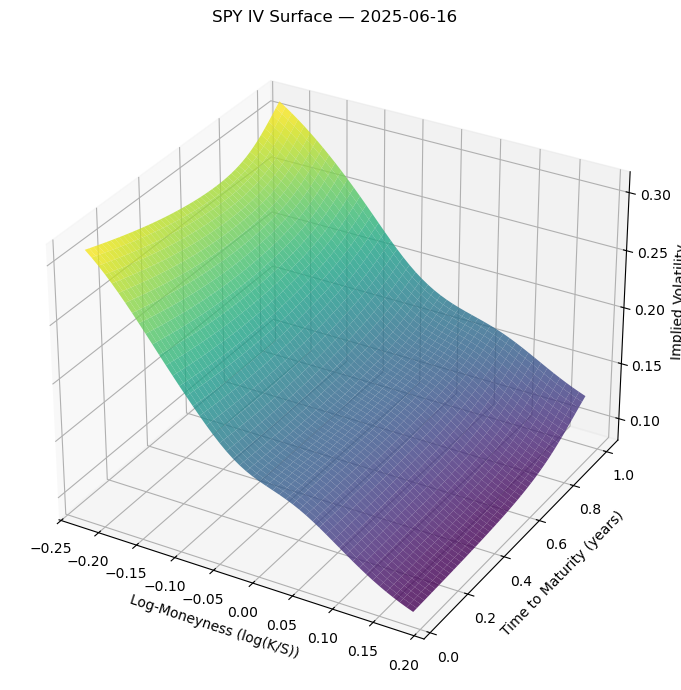

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Define the grid
log_moneyness_grid = np.linspace(np.log(0.80), np.log(1.20), 50)
ttm_grid = np.linspace(14/365, 1.0, 50)
M, T = np.meshgrid(log_moneyness_grid, ttm_grid)

# Nadaraya-Watson kernel smoothing
def nadaraya_watson(m_grid, t_grid, m_data, t_data, iv_data, h_m=0.05, h_t=0.1):
    surface = np.zeros((len(t_grid), len(m_grid)))
    for i, t in enumerate(t_grid):
        for j, m in enumerate(m_grid):
            w = np.exp(-0.5 * ((m_data - m) / h_m)**2) * \
                np.exp(-0.5 * ((t_data - t) / h_t)**2)
            if w.sum() > 0:
                surface[i, j] = np.dot(w, iv_data) / w.sum()
            else:
                surface[i, j] = np.nan
    return surface

IV_surface = nadaraya_watson(
    log_moneyness_grid, ttm_grid,
    df_filtered["log_moneyness"].values,
    df_filtered["TTM"].values,
    df_filtered["IV"].values
)

# Plot
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(M, T, IV_surface, cmap='viridis', alpha=0.8)
ax.set_xlabel("Log-Moneyness (log(K/S))")
ax.set_ylabel("Time to Maturity (years)")
ax.set_zlabel("Implied Volatility")
ax.set_title(f"SPY IV Surface — {date}")
plt.tight_layout()
plt.show()

In [30]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(
    x=log_moneyness_grid,
    y=ttm_grid,
    z=IV_surface,
    colorscale='Viridis',
    colorbar=dict(title='IV')
)])

fig.update_layout(
    title=f'SPY IV Surface — {date}',
    scene=dict(
        xaxis_title='log-Moneyness (K/S)',
        yaxis_title='Time to Maturity (years)',
        zaxis_title='Implied Volatility',
        camera=dict(eye=dict(x=1.5, y=-1.5, z=0.8))
    ),
    width=900,
    height=650
)

fig.show()